In [1]:
import pandas as pd

df = pd.read_csv("/home/yash/ML/Housing_Price_Prediction/data/house_price_prediction_dataset_3000_fixed.csv")
df = df.drop(columns = ["age_years"])

In [2]:
df.head()

,area_sqft,bedrooms,bathrooms,floors,garage,distance_from_city_km,condition,location,has_garden,has_pool,parking,year_built,price_inr
0,3674,6,4.0,2.0,3.0,22.3,4.0,Suburban,1,1,1,2004,56707000
1,4007,6,4.0,1.5,0.0,20.0,5.0,NaN,0,0,0,2005,55874000
2,1360,2,1.0,2.5,2.0,24.9,NaN,Urban,0,0,1,2023,21074000
3,1794,2,2.0,1.0,2.0,20.7,3.0,Urban,1,0,0,1993,24797000
4,1630,4,3.0,1.0,3.0,16.3,3.0,Suburban,0,1,1,2021,28868000


In [3]:
df.select_dtypes(include='number').corr()["price_inr"]

area_sqft                0.985930
bedrooms                 0.899899
bathrooms                0.823199
floors                  -0.008070
garage                   0.036943
distance_from_city_km   -0.046979
condition                0.056831
has_garden               0.013253
has_pool                 0.024720
parking                 -0.018002
year_built               0.060385
price_inr                1.000000
Name: price_inr, dtype: float64

In [4]:
df.isnull().sum()

area_sqft                 0
bedrooms                  0
bathrooms                60
floors                    0
garage                   60
distance_from_city_km     0
condition                60
location                 60
has_garden                0
has_pool                  0
parking                   0
year_built                0
price_inr                 0
dtype: int64

In [5]:
df["condition"] = df["condition"].fillna(df["condition"].median())
# Replace missing value of condition by it's median value.

In [6]:
df["garage"] = df["garage"].fillna("0")
# Replace missing value of garage by "0".

In [7]:
print("Missing values :\n",df[["location","garage","condition"]].isnull().sum())

Missing values :
 location     60
garage        0
condition     0
dtype: int64


In [8]:
print(
    f"Bathroom Column\n\n"
    f"- Mean : {df['bathrooms'].mean()}\n"
    f"- Median : {df['bathrooms'].median()}\n"
    f"- Mode : {df['bathrooms'].mode()}"
)

Bathroom Column

- Mean : 2.7540816326530613
- Median : 3.0
- Mode : 0    4.0
Name: bathrooms, dtype: float64


In [9]:
df.select_dtypes(include='number').corr()["bathrooms"]

area_sqft                0.810623
bedrooms                 0.910145
bathrooms                1.000000
floors                  -0.022828
distance_from_city_km   -0.008109
condition                0.003553
has_garden              -0.018307
has_pool                 0.005991
parking                 -0.008826
year_built              -0.015099
price_inr                0.823199
Name: bathrooms, dtype: float64

In [10]:
x = df.drop(columns=["price_inr"])
y = df["price_inr"]

In [11]:
# Split known data for training and missing data for predict their value 
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=0
)# Remove Price column to save data leakage 

In [12]:
bathroom_train = x_train[x_train["bathrooms"].notna()]
bathroom_missing_train = x_train[x_train["bathrooms"].isna()]
bathroom_x_train = bathroom_train.drop(columns=["bathrooms"])
bathroom_y_train = bathroom_train["bathrooms"]
bathroom_x_pred = bathroom_missing_train.drop(columns=["bathrooms"])

In [13]:
bathroom_x_train = bathroom_x_train.drop(columns=["location"])
bathroom_x_pred = bathroom_x_pred.drop(columns=["location"])

In [14]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)

lr.fit(bathroom_x_train, bathroom_y_train)

/home/yash/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [15]:
bathroom_predictions = lr.predict(bathroom_x_pred)

In [16]:
x_train.loc[x_train["bathrooms"].isna(),"bathrooms"] = bathroom_predictions

In [17]:
bathroom_test_missing = x_test[x_test["bathrooms"].isna()]

In [18]:
bathroom_test_x_pred = bathroom_test_missing.drop(columns=["bathrooms", "location"])

In [19]:
test_bathroom_predictions = lr.predict(bathroom_test_x_pred)

In [20]:
x_test.loc[x_test["bathrooms"].isna(),"bathrooms"] = test_bathroom_predictions

In [21]:
x_train.isnull().sum()

area_sqft                 0
bedrooms                  0
bathrooms                 0
floors                    0
garage                    0
distance_from_city_km     0
condition                 0
location                 45
has_garden                0
has_pool                  0
parking                   0
year_built                0
dtype: int64

In [22]:
x_train["location"].unique()

array(['Urban', 'Suburban', 'Rural', nan], dtype=object)

(location
 Suburban    988
 Urban       914
 Rural       453
 Name: count, dtype: int64,
 <Axes: xlabel='location'>)

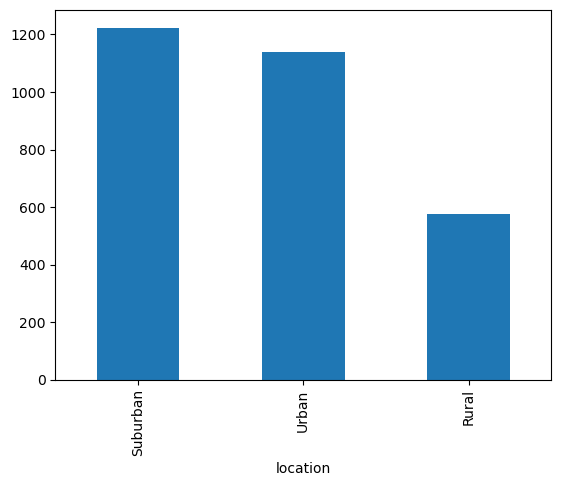

In [23]:
x_train["location"].value_counts(),df["location"].value_counts().plot(kind = "bar") 

In [24]:
x_train.isnull().sum()

area_sqft                 0
bedrooms                  0
bathrooms                 0
floors                    0
garage                    0
distance_from_city_km     0
condition                 0
location                 45
has_garden                0
has_pool                  0
parking                   0
year_built                0
dtype: int64

In [25]:
x_train.head(),x_test.head()

(      area_sqft  bedrooms  bathrooms  floors garage  distance_from_city_km  \
 2370       1598         3        3.0     2.0    2.0                   17.9   
 1774       1909         5        4.0     1.0    1.0                   13.9   
 731        3569         6        4.0     3.0    2.0                   11.1   
 271        1636         3        2.0     2.0    2.0                   23.0   
 1077        888         2        2.0     1.0    1.0                   20.0   
 
       condition  location  has_garden  has_pool  parking  year_built  
 2370        1.0     Urban           0         0        1        1991  
 1774        1.0  Suburban           1         0        1        1987  
 731         1.0  Suburban           1         0        1        1987  
 271         2.0  Suburban           0         0        0        2004  
 1077        2.0  Suburban           0         0        1        2017  ,
       area_sqft  bedrooms  bathrooms  floors garage  distance_from_city_km  \
 311        

In [26]:
from sklearn.compose import ColumnTransformer

In [27]:
x_train

,area_sqft,bedrooms,bathrooms,floors,garage,distance_from_city_km,condition,location,has_garden,has_pool,parking,year_built
2370,1598,3,3.0,2.0,2.0,17.9,1.0,Urban,0,0,1,1991
1774,1909,5,4.0,1.0,1.0,13.9,1.0,Suburban,1,0,1,1987
731,3569,6,4.0,3.0,2.0,11.1,1.0,Suburban,1,0,1,1987
271,1636,3,2.0,2.0,2.0,23.0,2.0,Suburban,0,0,0,2004
1077,888,2,2.0,1.0,1.0,20.0,2.0,Suburban,0,0,1,2017
...,...,...,...,...,...,...,...,...,...,...,...,...
763,3210,4,3.0,1.5,2.0,28.0,2.0,Rural,0,0,0,2001
835,3580,6,4.0,2.0,1.0,18.5,5.0,Suburban,1,0,1,1999
1653,2224,3,2.0,2.0,1.0,18.4,1.0,Suburban,1,0,1,1984
2607,2237,5,4.0,2.5,1.0,17.9,1.0,Urban,0,0,1,1985


In [28]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

trf = ColumnTransformer(
    transformers=[
        # ("Encoding",OrdinalEncoder(categories=[['Missing', 'Rural', 'Urban', 'Suburban']]),[7]),
        ("Encoding",OneHotEncoder(),[7]),
        ("Scale",StandardScaler(),[0,5,11]),

        ],
    remainder="passthrough")

In [29]:
from sklearn.pipeline import Pipeline

In [30]:
Pipeline = Pipeline([
     ("trf",trf)
    ])

In [31]:
Pipeline.fit(x_train,y_train)
x_train = Pipeline.transform(x_train)
x_test = Pipeline.transform(x_test)

In [32]:
pd.DataFrame(x_train)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.0,0.0,1.0,0.0,-0.807916,0.272123,-0.67982,3,3.0,2.0,2.0,1.0,0,0,1
1,0.0,1.0,0.0,0.0,-0.538096,-0.204024,-0.950071,5,4.0,1.0,1.0,1.0,1,0,1
2,0.0,1.0,0.0,0.0,0.902104,-0.537326,-0.950071,6,4.0,3.0,2.0,1.0,1,0,1
3,0.0,1.0,0.0,0.0,-0.774948,0.879209,0.198493,3,2.0,2.0,2.0,2.0,0,0,0
4,0.0,1.0,0.0,0.0,-1.423905,0.5221,1.076807,2,2.0,1.0,1.0,2.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,1.0,0.0,0.0,0.0,0.590639,1.474393,-0.004195,4,3.0,1.5,2.0,2.0,0,0,0
2396,0.0,1.0,0.0,0.0,0.911647,0.343545,-0.13932,6,4.0,2.0,1.0,5.0,1,0,1
2397,0.0,1.0,0.0,0.0,-0.264805,0.331641,-1.152758,3,2.0,2.0,1.0,1.0,1,0,1
2398,0.0,0.0,1.0,0.0,-0.253526,0.272123,-1.085196,5,4.0,2.5,1.0,1.0,0,0,1


## Check Multiple Model 

In [33]:
from sklearn.linear_model import Ridge,LinearRegression,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression" : LinearRegression(),
    "Ridge" : Ridge(alpha=13),
    "Lasso" : Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [34]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

for name,model in models.items():
    
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    
    print("Model Name : ",name)
    print("R2-Score   : ",r2_score(y_test,y_pred))
    print("MAE        : ",mean_absolute_error(y_test,y_pred))
    print("MSE        : ",mean_squared_error(y_test,y_pred),"\n")

Model Name :  Linear Regression
R2-Score   :  0.984816518620296
MAE        :  1454735.4187190684
MSE        :  3272784178719.19 

Model Name :  Ridge
R2-Score   :  0.9849411030401296
MAE        :  1446063.2567964918
MSE        :  3245930132012.111 

Model Name :  Lasso
R2-Score   :  0.9848165201524097
MAE        :  1454735.3105086538
MSE        :  3272783848473.5815 

Model Name :  Decision Tree
R2-Score   :  0.9561193777184134
MAE        :  2476006.6666666665
MSE        :  9458424110000.0 

Model Name :  Random Forest
R2-Score   :  0.9781377194923597
MAE        :  1748469.3333333333
MSE        :  4712392630307.333 

Model Name :  Gradient Boosting
R2-Score   :  0.9818947662428863
MAE        :  1584014.893178604
MSE        :  3902564972450.948 



#### Ridge Perform better so it apply on model 

In [35]:
r = Ridge()

from sklearn.model_selection import cross_val_score
cross_val_score(Ridge(),x_train,y_train,cv=5,scoring="r2").mean()*100

np.float64(98.59268268002552)

In [36]:
best = 0
r2 = 0
for alpha in range(0,100):
    r = Ridge(alpha=alpha)
    r.fit(x_train,y_train)
    if r2_score(y_test,r.predict(x_test))*100 > r2:
        r2 = r2_score(y_test,r.predict(x_test))*100
        best = alpha
    else :
        continue

In [37]:
best,r2

(14, 98.4941402814387)